In [1]:
# Disease Prediction — Binary Classification
# CloudExify Data Science Internship — Month 2, Project 4 (FINAL PROJECT)
# Logistic Regression vs Decision Tree

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc)
import matplotlib.pyplot as plt

df = pd.read_csv('disease_data.csv')

print(df.head())
print(df.shape)
print(df.info())

   Age  BloodPressure  Glucose   BMI  DiabetesPedigree  Disease
0   63            151      104  28.7              0.36        1
1   53            173      132  38.7              0.23        1
2   39            178       94  31.4              1.03        1
3   67            175      159  31.0              0.10        1
4   32            102      144  18.8              0.76        1
(600, 6)
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               600 non-null    int64  
 1   BloodPressure     600 non-null    int64  
 2   Glucose           600 non-null    int64  
 3   BMI               585 non-null    float64
 4   DiabetesPedigree  600 non-null    float64
 5   Disease           600 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 28.3 KB
None


In [3]:
df = df.dropna()

X = df.drop('Disease', axis=1)
y = df['Disease']

print("Class balance:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {len(X_train)}")
print(f"Test set: {len(X_test)}")

Class balance:
Disease
1    550
0     35
Name: count, dtype: int64

Training set: 468
Test set: 117


In [4]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results:")
print(f"  Accuracy:  {acc_lr:.3f}")
print(f"  Precision: {prec_lr:.3f}")
print(f"  Recall:    {rec_lr:.3f}")
print(f"  F1-Score:  {f1_lr:.3f}")

Logistic Regression Results:
  Accuracy:  0.949
  Precision: 0.964
  Recall:    0.982
  F1-Score:  0.973


In [5]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print(f"  Accuracy:  {acc_dt:.3f}")
print(f"  Precision: {prec_dt:.3f}")
print(f"  Recall:    {rec_dt:.3f}")
print(f"  F1-Score:  {f1_dt:.3f}")

Decision Tree Results:
  Accuracy:  0.915
  Precision: 0.946
  Recall:    0.964
  F1-Score:  0.955


Confusion Matrix:
[[  1   6]
 [  4 106]]
[[True Neg, False Pos]
 [False Neg, True Pos]]


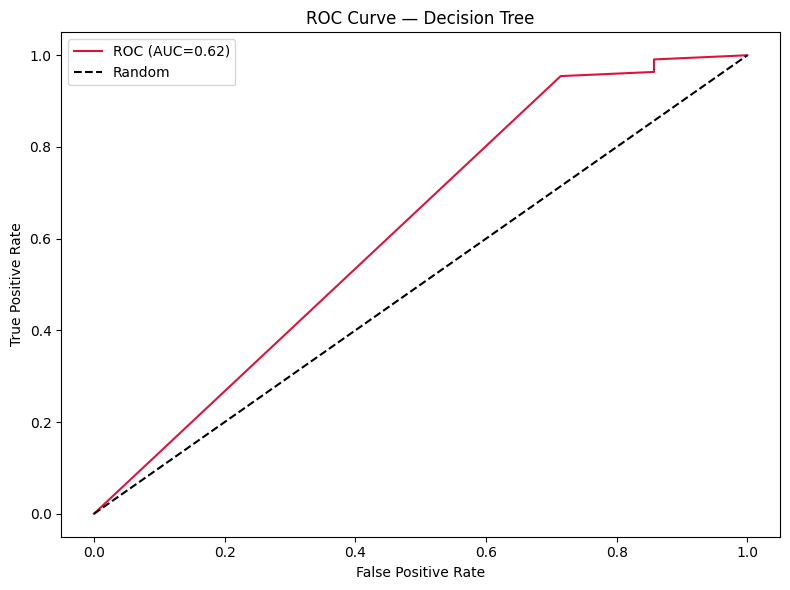

In [7]:
cm = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix:")
print(cm)
print("[[True Neg, False Pos]")
print(" [False Neg, True Pos]]")

y_pred_proba = dt_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.2f})', color='crimson')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Decision Tree')
plt.legend()
plt.tight_layout()
plt.show()

            Feature  Importance
2           Glucose    0.261137
3               BMI    0.259328
4  DiabetesPedigree    0.232995
1     BloodPressure    0.160448
0               Age    0.086091


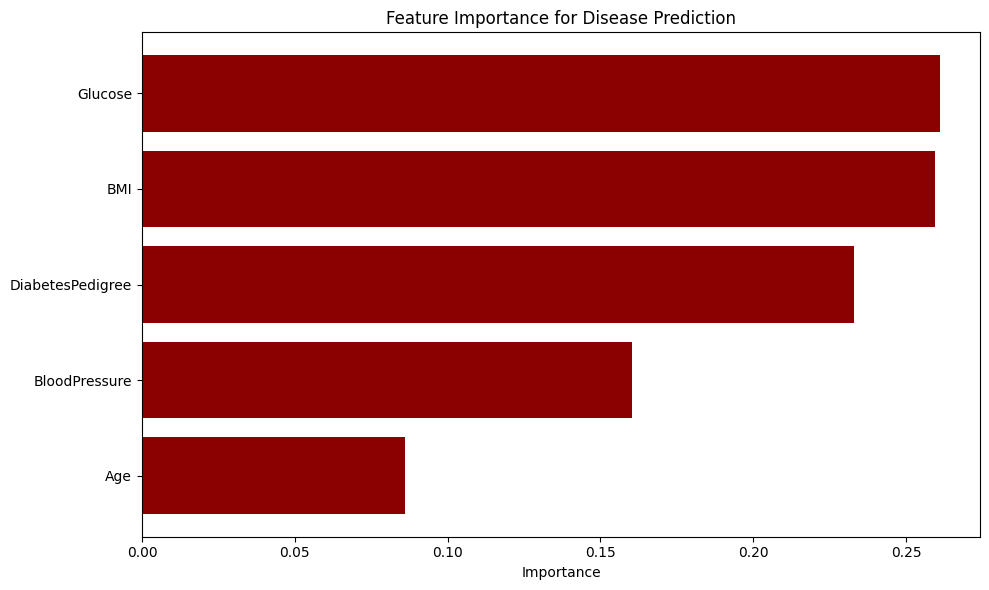

In [9]:
importances = dt_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='darkred')
plt.xlabel('Importance')
plt.title('Feature Importance for Disease Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
new_patient = pd.DataFrame({
    'Age': [45],
    'BloodPressure': [130],
    'Glucose': [110],
    'BMI': [28.5],
    'DiabetesPedigree': [0.42]
})

new_patient_scaled = pd.DataFrame(
    scaler.transform(new_patient),
    columns=new_patient.columns)

prediction = dt_model.predict(new_patient_scaled)
probability = dt_model.predict_proba(new_patient_scaled)[0, 1]

if prediction[0] == 1:
    print(f"DISEASE LIKELY (Probability: {probability:.1%})")
else:
    print(f"NO DISEASE (Probability: {1 - probability:.1%})")

NO DISEASE (Probability: 100.0%)
